In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\DELL\Downloads\synthetic_gross_profit_margin_classification_dataset.csv")
data.head()

,net_sales,cost_of_goods_sold,returns_and_allowances,discounts_given,shipping_expenses,inventory_beginning,inventory_ending,direct_labor_cost,direct_material_cost,overhead_cost,gross_profit_margin_level
0,1955006.697,2031763.725,72086.96660,74821.53323,68111.89022,196149.85810,111668.5608,255061.7795,126049.2806,95109.31823,Low
1,1536111.996,3384867.087,85709.19836,67643.51169,84482.17709,230520.62520,353071.0772,128448.4856,646526.7806,161641.15610,Low
2,4072004.914,2270939.277,85674.97166,59089.02201,97028.53281,383258.51540,207880.6627,246068.0292,581211.4598,188739.24100,High
3,3309888.563,1919858.903,10386.65891,31986.09978,55369.77659,55847.38022,162141.6359,244025.9319,194742.3673,38976.45456,High
4,4889347.101,3303039.895,92396.72153,34171.18575,131018.68850,260022.62330,355359.8850,137931.8298,603677.4627,117836.24180,Medium


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   net_sales                  500 non-null    float64
 1   cost_of_goods_sold         500 non-null    float64
 2   returns_and_allowances     500 non-null    float64
 3   discounts_given            500 non-null    float64
 4   shipping_expenses          500 non-null    float64
 5   inventory_beginning        500 non-null    float64
 6   inventory_ending           500 non-null    float64
 7   direct_labor_cost          500 non-null    float64
 8   direct_material_cost       500 non-null    float64
 9   overhead_cost              500 non-null    float64
 10  gross_profit_margin_level  500 non-null    object 
dtypes: float64(10), object(1)
memory usage: 43.1+ KB


In [4]:
dataset = data.isna().sum()
print("Missing values in each column:\n", dataset)

Missing values in each column:
 net_sales                    0
cost_of_goods_sold           0
returns_and_allowances       0
discounts_given              0
shipping_expenses            0
inventory_beginning          0
inventory_ending             0
direct_labor_cost            0
direct_material_cost         0
overhead_cost                0
gross_profit_margin_level    0
dtype: int64


In [5]:
data.head()

,net_sales,cost_of_goods_sold,returns_and_allowances,discounts_given,shipping_expenses,inventory_beginning,inventory_ending,direct_labor_cost,direct_material_cost,overhead_cost,gross_profit_margin_level
0,1955006.697,2031763.725,72086.96660,74821.53323,68111.89022,196149.85810,111668.5608,255061.7795,126049.2806,95109.31823,Low
1,1536111.996,3384867.087,85709.19836,67643.51169,84482.17709,230520.62520,353071.0772,128448.4856,646526.7806,161641.15610,Low
2,4072004.914,2270939.277,85674.97166,59089.02201,97028.53281,383258.51540,207880.6627,246068.0292,581211.4598,188739.24100,High
3,3309888.563,1919858.903,10386.65891,31986.09978,55369.77659,55847.38022,162141.6359,244025.9319,194742.3673,38976.45456,High
4,4889347.101,3303039.895,92396.72153,34171.18575,131018.68850,260022.62330,355359.8850,137931.8298,603677.4627,117836.24180,Medium


In [6]:
import matplotlib.pyplot as plt

In [ ]:
#  Descriptive stats for numeric variables
# ------------------------------
numeric_summary = data.describe()  # summary for all numeric columns
print("----- Numeric Features Summary -----")
print(numeric_summary)

----- Numeric Features Summary -----
          net_sales  cost_of_goods_sold  returns_and_allowances  \
count  5.000000e+02        5.000000e+02              500.000000   
mean   2.769507e+06        1.880284e+06            52490.946640   
std    1.283353e+06        9.393942e+05            27829.232546   
min    5.043932e+05        2.071224e+05             5280.697911   
25%    1.669087e+06        1.075770e+06            28266.676338   
50%    2.781272e+06        1.923468e+06            51966.702180   
75%    3.875694e+06        2.706877e+06            77080.761275   
max    4.994869e+06        3.499495e+06            99714.445750   

       discounts_given  shipping_expenses  inventory_beginning  \
count       500.000000         500.000000           500.000000   
mean      41070.816310       77986.280194        220261.830152   
std       22479.640247       40823.987720        100977.264905   
min        2068.970943       10065.368440         50034.618660   
25%       21679.603383       

In [8]:
#  Descriptive stats for categorical variable
# ------------------------------
categorical_summary = data['gross_profit_margin_level'].value_counts()  # counts per category
categorical_percentage = data['gross_profit_margin_level'].value_counts(normalize=True) * 100  # percentage

print("\n----- Categorical Feature: gross_profit_margin_level -----")
print("Counts:")
print(categorical_summary)
print("\nPercentage:")
print(categorical_percentage)


----- Categorical Feature: gross_profit_margin_level -----
Counts:
gross_profit_margin_level
Low       216
High      191
Medium     93
Name: count, dtype: int64

Percentage:
gross_profit_margin_level
Low       43.2
High      38.2
Medium    18.6
Name: proportion, dtype: float64


In [9]:
data.head()

,net_sales,cost_of_goods_sold,returns_and_allowances,discounts_given,shipping_expenses,inventory_beginning,inventory_ending,direct_labor_cost,direct_material_cost,overhead_cost,gross_profit_margin_level
0,1955006.697,2031763.725,72086.96660,74821.53323,68111.89022,196149.85810,111668.5608,255061.7795,126049.2806,95109.31823,Low
1,1536111.996,3384867.087,85709.19836,67643.51169,84482.17709,230520.62520,353071.0772,128448.4856,646526.7806,161641.15610,Low
2,4072004.914,2270939.277,85674.97166,59089.02201,97028.53281,383258.51540,207880.6627,246068.0292,581211.4598,188739.24100,High
3,3309888.563,1919858.903,10386.65891,31986.09978,55369.77659,55847.38022,162141.6359,244025.9319,194742.3673,38976.45456,High
4,4889347.101,3303039.895,92396.72153,34171.18575,131018.68850,260022.62330,355359.8850,137931.8298,603677.4627,117836.24180,Medium


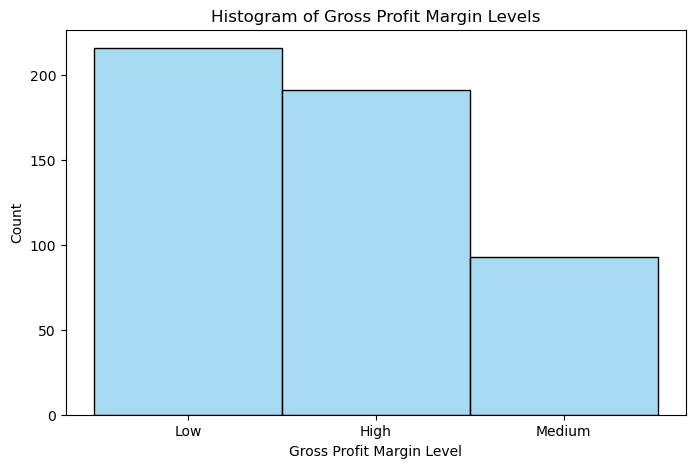

In [ ]:
#  Histogram of gross profit margins
# ---------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(data['gross_profit_margin_level'], bins=5, kde=False, color='skyblue')
plt.title("Histogram of Gross Profit Margin Levels")
plt.xlabel("Gross Profit Margin Level")
plt.ylabel("Count")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8804\2537789414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gross_profit_margin_level', y='net_sales', data=data, palette='pastel')


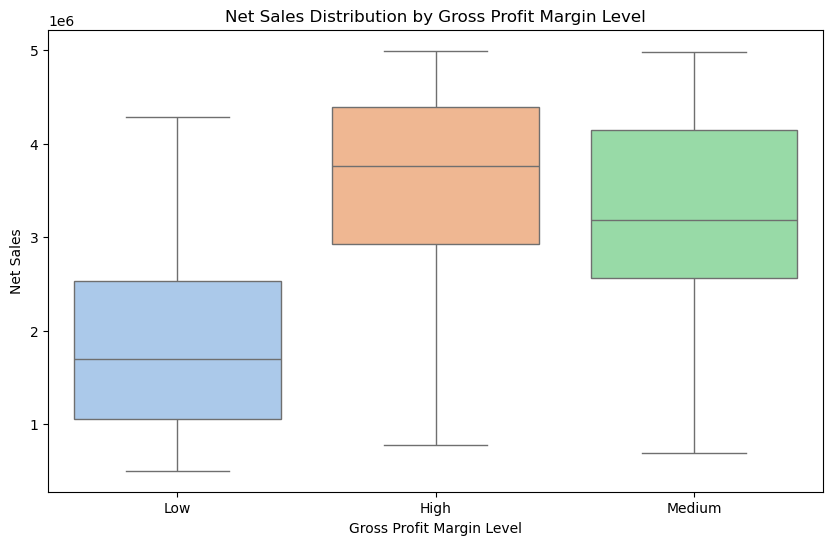

In [11]:
#  Trend line: Net Sales vs Gross Profit Margin Level
plt.figure(figsize=(10,6))
sns.boxplot(x='gross_profit_margin_level', y='net_sales', data=data, palette='pastel')
plt.title("Net Sales Distribution by Gross Profit Margin Level")
plt.xlabel("Gross Profit Margin Level")
plt.ylabel("Net Sales")
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler() 
data[['net_sales', 'cost_of_goods_sold', 'returns_and_allowances', 'discounts_given', 'shipping_expenses', 'inventory_beginning', 'inventory_ending', 'direct_labor_cost', 'direct_material_cost', 'overhead_cost']] = scaler.fit_transform(data[['net_sales', 'cost_of_goods_sold', 'returns_and_allowances', 'discounts_given', 'shipping_expenses', 'inventory_beginning', 'inventory_ending', 'direct_labor_cost', 'direct_material_cost', 'overhead_cost']]) 
data.head()

,net_sales,cost_of_goods_sold,returns_and_allowances,discounts_given,shipping_expenses,inventory_beginning,inventory_ending,direct_labor_cost,direct_material_cost,overhead_cost,gross_profit_margin_level
0,-0.635301,0.161414,0.704858,1.502894,-0.242119,-0.239025,-1.032661,1.068888,-1.487608,-0.364348,Low
1,-0.962035,1.603257,1.194841,1.183262,0.159279,0.101697,1.281064,-0.693771,1.339730,0.922625,Low
2,1.015934,0.416275,1.193610,0.802337,0.466915,1.615809,-0.110515,0.943680,0.984924,1.446803,High
3,0.421491,0.042170,-1.514467,-0.404536,-0.554555,-1.629863,-0.548902,0.915251,-1.114453,-1.450167,High
4,1.653452,1.516063,1.435388,-0.307235,1.300351,0.394154,1.303001,-0.561748,1.106964,0.075275,Medium


SELECT FEATURES AND TARGET

In [15]:
x = data.drop('gross_profit_margin_level', axis=1)
y = data['gross_profit_margin_level']   

GETTING TRAINING AND TEST SET

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)    
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (400, 10)
x_test shape: (100, 10)


In [24]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  # use same encoder for test

In [25]:
y_train_encoded

array([1, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 1,
       1, 0, 1, 1, 2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       2, 2, 0, 1, 0, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1, 0, 0, 1, 0, 2, 1, 0, 2, 1,
       2, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 1, 1,
       0, 0, 2, 0, 0, 1, 1, 1, 2, 1, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 2, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 2, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1, 1, 2, 1, 1,
       2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 2, 1, 0, 0, 2, 1, 1, 2, 0, 1, 2, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 2, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 0, 2, 1, 2,
       0, 0, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 1, 0, 1, 2, 0, 2, 0, 2, 0, 2,
       1, 0, 1, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0, 1,
       1, 1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1, 0, 1, 2,

BUILD MODEL

In [17]:
import xgboost as xgb

In [26]:
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)                              # for multi-class classification
# Fit the model
model.fit(x_train, y_train_encoded)

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:23:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

PREDICT MODEL

In [29]:
y_pred_encoded = model.predict(x_test)
print(y_pred_encoded[:10])

[0 0 0 0 0 2 1 0 1 1]


In [28]:
# Convert numeric predictions back to original labels
y_pred = le.inverse_transform(y_pred_encoded)

print(y_pred[:10])

['High' 'High' 'High' 'High' 'High' 'Medium' 'Low' 'High' 'Low' 'Low']


EVALUATE PERFORMANCE

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report 

In [32]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # weighted for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("----- Model Performance -----")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}\n")

----- Model Performance -----
Accuracy:  0.900
Precision: 0.918
Recall:    0.900
F1-score:  0.906



In [33]:
# Optional: detailed classification report
print("----- Classification Report -----")
print(classification_report(y_test, y_pred, target_names=le.classes_))

----- Classification Report -----
              precision    recall  f1-score   support

        High       1.00      0.92      0.96        36
         Low       0.94      0.90      0.92        51
      Medium       0.61      0.85      0.71        13

    accuracy                           0.90       100
   macro avg       0.85      0.89      0.86       100
weighted avg       0.92      0.90      0.91       100



In [35]:
from sklearn.metrics import confusion_matrix

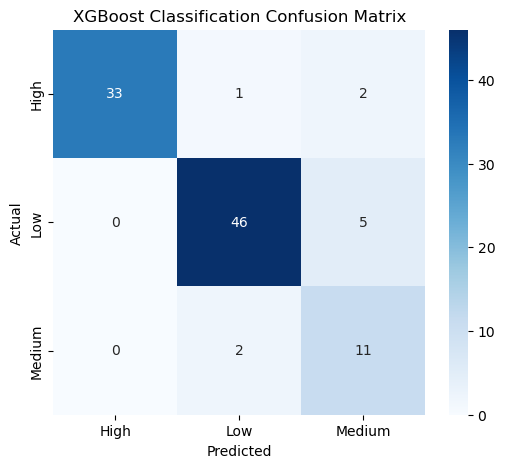

In [ ]:
#  Confusion matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Classification Confusion Matrix')
plt.show()

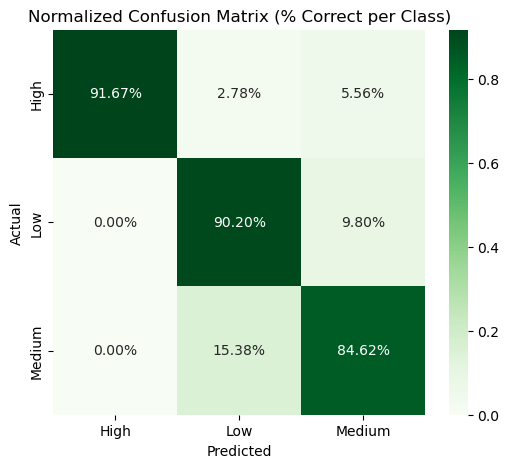

In [ ]:
#  Normalized Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix (% Correct per Class)')
plt.show()